# 1.1 Daily Accounting Panel, Feb 2026 To Jun 2026

This notebook builds the first large-window accounting panel for the demand-model work.

The point is to make the accounting objects explicit:

| Object | Meaning | Status in this notebook |
|---|---|---|
| `current_state_creation_gas` | historical gas charged for state creation under the current schedule | Xatu estimate |
| `state_gas_8037` | counterfactual EIP-8037 state gas | Xatu estimate |
| `current_execution_gas` | current gas after removing historical state-creation gas | Xatu estimate |
| `execution_gas_8037_7976_lower_bound` | current execution gas plus transaction-level EIP-7976 calldata floor uplift | Xatu lower bound |
| `execution_gas_8037_7976_7981` | full Glamsterdam regular gas including EIP-7981 access-list data surcharge | requires RPC calibration |
| `bandwidth_*_bytes` | calldata/blob/access/auth/BAL byte breakdown | calldata + blob from Xatu; others missing here |

Window:

```text
start = 2026-02-01 inclusive
end   = 2026-06-01 exclusive
```

This is a scalable Xatu-only panel. It intentionally skips BAL tracing and does not pretend Xatu exposes access lists or authorization lists.


## Setup

Raw Xatu is used for canonical execution headers, calldata/blob-hash transaction fields, receipt gas, and state-diff counters. CBT is used only for state-size inventory diagnostics.


In [1]:
import os
from pathlib import Path
import sys

import clickhouse_connect
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

pd.options.display.float_format = "{:,.4f}".format

load_dotenv(PROJECT_ROOT / ".env")
missing = [name for name in ["CLICKHOUSE_USER", "CLICKHOUSE_PASSWORD"] if not os.environ.get(name)]
if missing:
    raise RuntimeError("Missing .env values: " + ", ".join(missing))

CLICKHOUSE_CBT_HOST = os.environ.get("CLICKHOUSE_CBT_HOST", "clickhouse-cbt.xatu.ethpandaops.io")
CLICKHOUSE_RAW_HOST = os.environ.get("CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io")

cbt_client = clickhouse_connect.get_client(
    host=CLICKHOUSE_CBT_HOST,
    port=443,
    secure=True,
    username=os.environ["CLICKHOUSE_USER"],
    password=os.environ["CLICKHOUSE_PASSWORD"],
)
raw_client = clickhouse_connect.get_client(
    host=CLICKHOUSE_RAW_HOST,
    port=443,
    secure=True,
    username=os.environ["CLICKHOUSE_USER"],
    password=os.environ["CLICKHOUSE_PASSWORD"],
)

print("cbt", CLICKHOUSE_CBT_HOST, cbt_client.query("SELECT version()").result_rows)
print("raw", CLICKHOUSE_RAW_HOST, raw_client.query("SELECT version()").result_rows)


cbt clickhouse-cbt.xatu.ethpandaops.io [('26.2.5.45',)]
raw clickhouse-raw.xatu.ethpandaops.io [('26.2.5.45',)]


## Parameters

`REFRESH_COMPONENTS = False` reuses cached component CSVs. Set it to `True` to re-query Xatu.


In [2]:
NETWORK = "mainnet"
START_DATE = "2026-02-01"
END_DATE = "2026-06-01"  # exclusive
CPSB = 1530

REFRESH_COMPONENTS = False
WRITE_CSV = True

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

TAG = f"{START_DATE}_{END_DATE}"
HEADERS_CSV = DATA_DIR / f"daily_headers_raw_{TAG}.csv"
TX_CONTENT_CSV = DATA_DIR / f"daily_calldata_blob_xatu_{TAG}.csv"
CALLDATA_FLOOR_CSV = DATA_DIR / f"daily_eip7976_floor_xatu_{TAG}.csv"
STATE_CORE_CSV = DATA_DIR / f"daily_state_core_xatu_{TAG}.csv"
ACCOUNT_PROXY_CSV = DATA_DIR / f"daily_new_account_proxy_xatu_{TAG}.csv"
STATE_INVENTORY_CSV = DATA_DIR / f"daily_state_inventory_xatu_{TAG}.csv"
PANEL_CSV = DATA_DIR / f"daily_accounting_panel_{TAG}.csv"
SUMMARY_CSV = DATA_DIR / f"daily_accounting_summary_{TAG}.csv"

STATE_EXECUTION_PLOT = PLOTS_DIR / f"daily_accounting_state_execution_{TAG}.png"
BANDWIDTH_BYTES_PLOT = PLOTS_DIR / f"daily_accounting_bandwidth_bytes_{TAG}.png"

START_TS = f"{START_DATE} 00:00:00"
END_TS = f"{END_DATE} 00:00:00"
START_TS, END_TS


('2026-02-01 00:00:00', '2026-06-01 00:00:00')

## Resolve Block Range And Coverage

This maps the date window onto canonical execution block numbers and checks that raw transaction rows and canonical receipt rows have matching transaction counts.


In [3]:
block_range = raw_client.query_df(
    """
    SELECT
        count() AS blocks,
        min(block_number) AS min_block,
        max(block_number) AS max_block
    FROM default.canonical_execution_block FINAL
    WHERE meta_network_name = {network:String}
      AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
      AND block_date_time < parseDateTime64BestEffort({end_ts:String})
    """,
    parameters={"network": NETWORK, "start_ts": START_TS, "end_ts": END_TS},
)
MIN_BLOCK = int(block_range.loc[0, "min_block"])
MAX_BLOCK = int(block_range.loc[0, "max_block"])
N_BLOCKS = int(block_range.loc[0, "blocks"])
block_range


,blocks,min_block,max_block
0,860505,24358293,25218797


In [4]:
coverage = raw_client.query_df(
    """
    WITH raw_counts AS (
        SELECT block_number, count() AS raw_tx_count
        FROM default.execution_transaction FINAL
        WHERE meta_network_name = {network:String}
          AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
        GROUP BY block_number
    ),
    receipt_counts AS (
        SELECT block_number, count() AS receipt_tx_count
        FROM default.canonical_execution_transaction FINAL
        WHERE meta_network_name = {network:String}
          AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
        GROUP BY block_number
    )
    SELECT
        count() AS blocks_with_raw_transactions,
        sum(raw_tx_count) AS raw_txs,
        sum(receipt_tx_count) AS receipt_txs,
        countIf(raw_tx_count != receipt_tx_count) AS blocks_with_mismatch,
        sum(abs(toInt64(raw_tx_count) - toInt64(receipt_tx_count))) AS tx_count_abs_delta
    FROM raw_counts
    LEFT JOIN receipt_counts USING block_number
    """,
    parameters={"network": NETWORK, "min_block": MIN_BLOCK, "max_block": MAX_BLOCK},
)
coverage


,blocks_with_raw_transactions,raw_txs,receipt_txs,blocks_with_mismatch,tx_count_abs_delta
0,860177,270776698,270776698,0,0


## Load Or Query Component Tables

The component tables are cached because the first-seen account proxy is the slow part. The final panel is rebuilt from these components each run.


In [5]:
def normalize_date_column(df: pd.DataFrame) -> pd.DataFrame:
    if "date" in df.columns:
        df = df.copy()
        df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")
    return df


def load_or_query_csv(path: Path, query_fn):
    if path.exists() and not REFRESH_COMPONENTS:
        print("loaded", path)
        return normalize_date_column(pd.read_csv(path))
    df = normalize_date_column(query_fn())
    if WRITE_CSV:
        df.to_csv(path, index=False)
        print("wrote", path)
    return df


## Current Header / Price / Total Gas

This is the anchor for current demand level and base fee.


In [6]:
def query_headers():
    return raw_client.query_df(
        """
        SELECT
            toDate(block_date_time) AS date,
            count() AS block_count,
            min(block_number) AS min_block,
            max(block_number) AS max_block,
            sum(gas_used) AS current_gas_used,
            avg(gas_used) AS mean_current_gas_used,
            avg(gas_limit) AS mean_gas_limit,
            avg(toFloat64(base_fee_per_gas)) AS mean_base_fee_per_gas,
            quantileExact(0.5)(toFloat64(base_fee_per_gas)) AS median_base_fee_per_gas,
            sum(toFloat64(base_fee_per_gas) * toFloat64(gas_used))
                / nullIf(sum(toFloat64(gas_used)), 0) AS gas_weighted_base_fee_per_gas
        FROM default.canonical_execution_block FINAL
        WHERE meta_network_name = {network:String}
          AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
          AND block_date_time < parseDateTime64BestEffort({end_ts:String})
        GROUP BY date
        ORDER BY date
        """,
        parameters={"network": NETWORK, "start_ts": START_TS, "end_ts": END_TS},
    )

headers = load_or_query_csv(HEADERS_CSV, query_headers)
headers.head()


loaded /Users/william/PycharmProjects/eip-7999-research/data/daily_headers_raw_2026-02-01_2026-06-01.csv


,date,block_count,min_block,max_block,current_gas_used,mean_current_gas_used,mean_gas_limit,mean_base_fee_per_gas,median_base_fee_per_gas,gas_weighted_base_fee_per_gas
0,2026-02-01,7161,24358293,24365453,217479380384,"30,369,973.5210","59,992,399.6688","312,040,649.3847","148,863,401.0000","308,235,484.2166"
1,2026-02-02,7160,24365454,24372613,217513933432,"30,379,040.9821","59,992,300.5355","421,188,671.3568","182,441,382.0000","415,832,077.5647"
2,2026-02-03,7149,24372614,24379762,217550972098,"30,430,965.4634","59,992,862.1018","372,465,699.3296","153,347,493.0000","367,281,509.8576"
3,2026-02-04,7152,24379763,24386914,217388293492,"30,395,454.9066","59,992,906.2412","326,003,921.7904","176,883,399.0000","321,631,383.2971"
4,2026-02-05,7150,24386915,24394064,218008643698,"30,490,719.3983","59,992,052.0102","2,741,992,077.9646","911,560,861.0000","2,698,951,128.0006"


## Bandwidth Content Available From Xatu

Calldata zero/nonzero bytes and blob versioned hashes come from raw `execution_transaction`.

This is not the full bandwidth resource yet. Access-list bytes, authorization tuple bytes, and BAL bytes are missing from this Xatu-only panel.


In [7]:
def query_tx_content():
    return raw_client.query_df(
        """
        WITH tx_by_block AS
        (
            SELECT
                block_number,
                count() AS tx_count,
                countIf(n_input_bytes > 0) AS txs_with_calldata,
                countIf(type = 4) AS type4_tx_count,
                sum(n_input_bytes) AS calldata_bytes,
                sum(n_input_zero_bytes) AS calldata_zero_bytes,
                sum(n_input_nonzero_bytes) AS calldata_nonzero_bytes,
                sum(4 * n_input_zero_bytes + 16 * n_input_nonzero_bytes) AS standard_calldata_gas,
                sum(length(blob_hashes)) AS blob_versioned_hash_count
            FROM default.execution_transaction FINAL
            WHERE meta_network_name = {network:String}
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
            GROUP BY block_number
        )
        SELECT
            toDate(b.block_date_time) AS date,
            sum(ifNull(t.tx_count, 0)) AS tx_count,
            sum(ifNull(t.txs_with_calldata, 0)) AS txs_with_calldata,
            sum(ifNull(t.type4_tx_count, 0)) AS type4_tx_count,
            sum(ifNull(t.calldata_bytes, 0)) AS calldata_bytes,
            sum(ifNull(t.calldata_zero_bytes, 0)) AS calldata_zero_bytes,
            sum(ifNull(t.calldata_nonzero_bytes, 0)) AS calldata_nonzero_bytes,
            sum(ifNull(t.standard_calldata_gas, 0)) AS standard_calldata_gas,
            sum(ifNull(t.blob_versioned_hash_count, 0)) AS blob_versioned_hash_count
        FROM default.canonical_execution_block AS b FINAL
        GLOBAL LEFT JOIN tx_by_block AS t USING block_number
        WHERE b.meta_network_name = {network:String}
          AND b.block_date_time >= parseDateTime64BestEffort({start_ts:String})
          AND b.block_date_time < parseDateTime64BestEffort({end_ts:String})
        GROUP BY date
        ORDER BY date
        """,
        parameters={
            "network": NETWORK,
            "start_ts": START_TS,
            "end_ts": END_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
        },
    )

tx_content = load_or_query_csv(TX_CONTENT_CSV, query_tx_content)
tx_content["blob_versioned_hash_bytes"] = tx_content["blob_versioned_hash_count"] * 32
tx_content["bandwidth_known_bytes_no_bal"] = tx_content["calldata_bytes"] + tx_content["blob_versioned_hash_bytes"]
tx_content.head()


loaded /Users/william/PycharmProjects/eip-7999-research/data/daily_calldata_blob_xatu_2026-02-01_2026-06-01.csv


,date,tx_count,txs_with_calldata,type4_tx_count,calldata_bytes,calldata_zero_bytes,calldata_nonzero_bytes,standard_calldata_gas,blob_versioned_hash_count,blob_versioned_hash_bytes,bandwidth_known_bytes_no_bal
0,2026-02-01,2538407,1339859,9433,748121362,475704113,272417249,6261492436,33346,1067072,749188434
1,2026-02-02,2308687,1305734,8600,791365953,496445279,294920674,6704511900,34743,1111776,792477729
2,2026-02-03,2563472,1305450,8332,786407615,486529886,299877729,6744163208,35307,1129824,787537439
3,2026-02-04,2489539,1318402,7203,810410876,496832258,313578618,7004586920,34855,1115360,811526236
4,2026-02-05,2263196,1357674,7030,823132195,526646535,296485660,6850356700,44596,1427072,824559267


## EIP-7976 Calldata Floor Uplift

For `8037_execution_gas`, we need the Glamsterdam regular-gas side, not just current receipt gas.

This query computes a scalable Xatu lower bound for EIP-7976:

```text
eip7976_floor_uplift_current_body = max(0, 64 * calldata_bytes - current_receipt_body_gas)
```

It is a lower bound because exact Glamsterdam regular gas should apply the floor after transaction-level state-creation gas is removed. This notebook subtracts state at the daily level, so the exact transaction-level floor-after-state term remains a future refinement.

EIP-7981 is not included here because Xatu does not expose transaction access lists.


In [8]:
def query_calldata_floor():
    return raw_client.query_df(
        """
        WITH tx_by_block AS
        (
            SELECT
                block_number,
                count() AS tx_count_receipts,
                sum(gas_used) AS receipt_gas_used,
                sum(greatest(0, (64 * n_input_bytes) - greatest(toInt64(gas_used) - 21000, 0))) AS eip7976_floor_uplift_current_body,
                countIf((64 * n_input_bytes) > greatest(toInt64(gas_used) - 21000, 0)) AS eip7976_floor_bound_txs_current_body
            FROM default.canonical_execution_transaction FINAL
            WHERE meta_network_name = {network:String}
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
            GROUP BY block_number
        )
        SELECT
            toDate(b.block_date_time) AS date,
            sum(ifNull(t.tx_count_receipts, 0)) AS tx_count_receipts,
            sum(ifNull(t.receipt_gas_used, 0)) AS receipt_gas_used,
            sum(ifNull(t.eip7976_floor_uplift_current_body, 0)) AS eip7976_floor_uplift_current_body,
            sum(ifNull(t.eip7976_floor_bound_txs_current_body, 0)) AS eip7976_floor_bound_txs_current_body
        FROM default.canonical_execution_block AS b FINAL
        GLOBAL LEFT JOIN tx_by_block AS t USING block_number
        WHERE b.meta_network_name = {network:String}
          AND b.block_date_time >= parseDateTime64BestEffort({start_ts:String})
          AND b.block_date_time < parseDateTime64BestEffort({end_ts:String})
        GROUP BY date
        ORDER BY date
        """,
        parameters={
            "network": NETWORK,
            "start_ts": START_TS,
            "end_ts": END_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
        },
        settings={"max_execution_time": 180},
    )

calldata_floor = load_or_query_csv(CALLDATA_FLOOR_CSV, query_calldata_floor)
calldata_floor.head()


wrote /Users/william/PycharmProjects/eip-7999-research/data/daily_eip7976_floor_xatu_2026-02-01_2026-06-01.csv


,date,tx_count_receipts,receipt_gas_used,eip7976_floor_uplift_current_body,eip7976_floor_bound_txs_current_body
0,2026-02-01,2538407,217479380384,4195293096,50753
1,2026-02-02,2308687,217513933432,5205823870,46335
2,2026-02-03,2563472,217550972098,5218017231,47542
3,2026-02-04,2489539,217388293492,5716665249,48750
4,2026-02-05,2263196,218008643698,5546616643,54071


## State Creation: Current Gas And EIP-8037 Gas

This section builds the state side explicitly.

Current state-creation gas uses the historical schedule:

```text
20_000 * new_storage_slots
+ 25_000 * new_accounts
+ 200 * code_bytes
+ 12_500 * new_delegation_indicators
```

EIP-8037 state gas uses:

```text
1530 * (64 * new_storage_slots
      + 120 * new_accounts
      + code_bytes
      + 23 * new_delegation_indicators)
```

`new_accounts` is the Xatu first-seen proxy. `new_delegation_indicators` is zero in this Xatu-only panel and needs RPC calibration.


In [9]:
ZERO_WORD = "0x" + "00" * 32


def query_state_core():
    return raw_client.query_df(
        """
        WITH blocks AS
        (
            SELECT block_number, toDate(block_date_time) AS date
            FROM default.canonical_execution_block FINAL
            WHERE meta_network_name = {network:String}
              AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
              AND block_date_time < parseDateTime64BestEffort({end_ts:String})
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
        ),
        storage_by_block AS
        (
            SELECT
                block_number,
                uniqExact(tuple(lower(address), lower(slot))) AS new_storage_slots,
                count() AS zero_to_nonzero_storage_writes
            FROM default.canonical_execution_storage_diffs FINAL
            WHERE meta_network_name = {network:String}
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
              AND lower(from_value) = {zero_word:String}
              AND lower(to_value) != {zero_word:String}
            GROUP BY block_number
        ),
        code_by_block AS
        (
            SELECT
                block_number,
                uniqExact(lower(contract_address)) AS new_contract_accounts,
                sum(n_code_bytes) AS code_bytes
            FROM default.canonical_execution_contracts FINAL
            WHERE meta_network_name = {network:String}
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
            GROUP BY block_number
        )
        SELECT
            b.date AS date,
            sum(ifNull(s.new_storage_slots, 0)) AS new_storage_slots,
            sum(ifNull(s.zero_to_nonzero_storage_writes, 0)) AS zero_to_nonzero_storage_writes,
            sum(ifNull(c.new_contract_accounts, 0)) AS new_contract_accounts,
            sum(ifNull(c.code_bytes, 0)) AS code_bytes
        FROM blocks AS b
        GLOBAL LEFT JOIN storage_by_block AS s USING block_number
        GLOBAL LEFT JOIN code_by_block AS c USING block_number
        GROUP BY date
        ORDER BY date
        """,
        parameters={
            "network": NETWORK,
            "start_ts": START_TS,
            "end_ts": END_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
            "zero_word": ZERO_WORD,
        },
    )

state_core = load_or_query_csv(STATE_CORE_CSV, query_state_core)
state_core.head()


loaded /Users/william/PycharmProjects/eip-7999-research/data/daily_state_core_xatu_2026-02-01_2026-06-01.csv


,date,new_storage_slots,zero_to_nonzero_storage_writes,new_contract_accounts,code_bytes
0,2026-02-01,1014876,1014908,8168,11108660
1,2026-02-02,933251,933271,10882,10193638
2,2026-02-03,1011079,1011101,12114,13755361
3,2026-02-04,864182,864213,9868,12600669
4,2026-02-05,879191,879238,13630,9996011


In [10]:
def query_account_proxy():
    return raw_client.query_df(
        """
        WITH
            blocks AS
            (
                SELECT block_number, toDate(block_date_time) AS date
                FROM default.canonical_execution_block FINAL
                WHERE meta_network_name = {network:String}
                  AND block_date_time >= parseDateTime64BestEffort({start_ts:String})
                  AND block_date_time < parseDateTime64BestEffort({end_ts:String})
                  AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
            ),
            candidates AS
            (
                SELECT address, min(candidate_block) AS candidate_block
                FROM
                (
                    SELECT lower(contract_address) AS address, min(block_number) AS candidate_block
                    FROM default.canonical_execution_contracts FINAL
                    WHERE meta_network_name = {network:String}
                      AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                    GROUP BY address
                    UNION ALL
                    SELECT lower(address) AS address, min(block_number) AS candidate_block
                    FROM default.canonical_execution_balance_diffs FINAL
                    WHERE meta_network_name = {network:String}
                      AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                      AND from_value = 0
                      AND to_value > 0
                    GROUP BY address
                    UNION ALL
                    SELECT lower(address) AS address, min(block_number) AS candidate_block
                    FROM default.canonical_execution_nonce_diffs FINAL
                    WHERE meta_network_name = {network:String}
                      AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                      AND from_value = 0
                      AND to_value > 0
                    GROUP BY address
                )
                GROUP BY address
            ),
            first_appearances AS
            (
                SELECT lower(address) AS address, min(block_number) AS first_block
                FROM default.canonical_execution_address_appearances FINAL
                WHERE meta_network_name = {network:String}
                  AND lower(address) GLOBAL IN (SELECT address FROM candidates)
                GROUP BY address
            ),
            new_accounts_by_block AS
            (
                SELECT c.candidate_block AS block_number, count() AS new_accounts_first_seen_proxy
                FROM candidates AS c
                INNER JOIN first_appearances AS f USING address
                WHERE f.first_block BETWEEN {min_block:UInt64} AND {max_block:UInt64}
                GROUP BY c.candidate_block
            ),
            candidate_counts_by_block AS
            (
                SELECT candidate_block AS block_number, count() AS raw_new_account_candidates
                FROM candidates
                GROUP BY candidate_block
            )
        SELECT
            b.date AS date,
            sum(ifNull(n.new_accounts_first_seen_proxy, 0)) AS new_accounts_first_seen_proxy,
            sum(ifNull(c.raw_new_account_candidates, 0)) AS raw_new_account_candidates
        FROM blocks AS b
        GLOBAL LEFT JOIN new_accounts_by_block AS n USING block_number
        GLOBAL LEFT JOIN candidate_counts_by_block AS c USING block_number
        GROUP BY date
        ORDER BY date
        """,
        parameters={
            "network": NETWORK,
            "start_ts": START_TS,
            "end_ts": END_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
        },
        settings={"max_execution_time": 180},
    )

account_proxy = load_or_query_csv(ACCOUNT_PROXY_CSV, query_account_proxy)
account_proxy.head()


loaded /Users/william/PycharmProjects/eip-7999-research/data/daily_new_account_proxy_xatu_2026-02-01_2026-06-01.csv


,date,new_accounts_first_seen_proxy,raw_new_account_candidates
0,2026-02-01,422267,510058
1,2026-02-02,378799,430564
2,2026-02-03,425979,478296
3,2026-02-04,405851,444636
4,2026-02-05,306796,338208


## State Inventory Diagnostics

These cumulative inventory columns are net diagnostics. They help sanity-check the account proxy, but they are not the replay-facing state-gas input.


In [11]:
def query_state_inventory():
    return cbt_client.query_df(
        """
        SELECT
            toDate(b.block_date_time) AS date,
            argMin(s.accounts, s.block_number) AS start_accounts,
            argMax(s.accounts, s.block_number) AS end_accounts,
            argMin(s.storages, s.block_number) AS start_storages,
            argMax(s.storages, s.block_number) AS end_storages,
            argMin(s.contract_code_bytes, s.block_number) AS start_contract_code_bytes,
            argMax(s.contract_code_bytes, s.block_number) AS end_contract_code_bytes,
            argMin(s.storage_bytes, s.block_number) AS start_storage_bytes,
            argMax(s.storage_bytes, s.block_number) AS end_storage_bytes
        FROM mainnet.int_execution_state_size_by_block AS s
        GLOBAL INNER JOIN
        (
            SELECT block_number, block_date_time
            FROM mainnet.int_execution_block_by_date
            WHERE block_date_time >= parseDateTime64BestEffort({start_ts:String})
              AND block_date_time < parseDateTime64BestEffort({end_ts:String})
              AND block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
        ) AS b USING block_number
        WHERE s.block_number BETWEEN {min_block:UInt64} AND {max_block:UInt64}
        GROUP BY date
        ORDER BY date
        """,
        parameters={
            "start_ts": START_TS,
            "end_ts": END_TS,
            "min_block": MIN_BLOCK,
            "max_block": MAX_BLOCK,
        },
    )

state_inventory = load_or_query_csv(STATE_INVENTORY_CSV, query_state_inventory)
for col in ["accounts", "storages", "contract_code_bytes", "storage_bytes"]:
    state_inventory[f"{col}_net_delta"] = state_inventory[f"end_{col}"] - state_inventory[f"start_{col}"]
state_inventory.head()


loaded /Users/william/PycharmProjects/eip-7999-research/data/daily_state_inventory_xatu_2026-02-01_2026-06-01.csv


,date,start_accounts,end_accounts,start_storages,end_storages,start_contract_code_bytes,end_contract_code_bytes,start_storage_bytes,end_storage_bytes,accounts_net_delta,storages_net_delta,contract_code_bytes_net_delta,storage_bytes_net_delta
0,2026-02-01,354549350,354971822,1488142763,1488730617,12784231319,12792230706,115099363607,115144550391,422472,587854,7999387,45186784
1,2026-02-02,354971882,355349981,1488730617,1489231796,12792230816,12798993366,115144550398,115183128238,378099,501179,6762550,38577840
2,2026-02-03,355349995,355775092,1489231797,1489813538,12798993366,12807860416,115183128462,115227770709,425097,581741,8867050,44642247
3,2026-02-04,355775150,356180288,1489813605,1490282843,12807860416,12816807750,115227775380,115264865146,405138,469238,8947334,37089766
4,2026-02-05,356180351,356486315,1490282860,1490736101,12816807750,12823827724,115264866427,115300626243,305964,453241,7019974,35759816


## Assemble Explicit Accounting Panel

This is the important table. It has four groups:

1. **current state vs EIP-8037 state**
2. **current execution vs Glamsterdam execution lower bound**
3. **known bandwidth bytes**
4. **missing RPC-only bandwidth/state components**


In [12]:
panel = headers.merge(tx_content, on="date", how="left")
panel = panel.merge(calldata_floor, on="date", how="left")
panel = panel.merge(state_core, on="date", how="left")
panel = panel.merge(account_proxy, on="date", how="left")
panel = panel.merge(state_inventory, on="date", how="left")

numeric_cols = [col for col in panel.columns if col != "date"]
panel[numeric_cols] = panel[numeric_cols].apply(pd.to_numeric, errors="coerce")

fill_zero_cols = [
    "tx_count",
    "txs_with_calldata",
    "type4_tx_count",
    "calldata_bytes",
    "calldata_zero_bytes",
    "calldata_nonzero_bytes",
    "standard_calldata_gas",
    "blob_versioned_hash_count",
    "blob_versioned_hash_bytes",
    "bandwidth_known_bytes_no_bal",
    "tx_count_receipts",
    "receipt_gas_used",
    "eip7976_floor_uplift_current_body",
    "eip7976_floor_bound_txs_current_body",
    "new_storage_slots",
    "zero_to_nonzero_storage_writes",
    "new_contract_accounts",
    "code_bytes",
    "new_accounts_first_seen_proxy",
    "raw_new_account_candidates",
]
for col in fill_zero_cols:
    panel[col] = panel[col].fillna(0)

# State side.
panel["new_accounts"] = panel["new_accounts_first_seen_proxy"]
panel["new_delegation_indicators"] = 0

panel["current_state_creation_gas"] = (
    20_000 * panel["new_storage_slots"]
    + 25_000 * panel["new_accounts"]
    + 200 * panel["code_bytes"]
    + 12_500 * panel["new_delegation_indicators"]
)
panel["storage_slot_state_bytes_8037"] = 64 * panel["new_storage_slots"]
panel["new_account_state_bytes_8037"] = 120 * panel["new_accounts"]
panel["code_deposit_state_bytes_8037"] = panel["code_bytes"]
panel["delegation_indicator_state_bytes_8037"] = 23 * panel["new_delegation_indicators"]
panel["state_bytes_equivalent_8037"] = (
    panel["storage_slot_state_bytes_8037"]
    + panel["new_account_state_bytes_8037"]
    + panel["code_deposit_state_bytes_8037"]
    + panel["delegation_indicator_state_bytes_8037"]
)
panel["state_gas_8037"] = CPSB * panel["state_bytes_equivalent_8037"]

# Execution / regular-gas side.
panel["current_execution_gas"] = panel["current_gas_used"] - panel["current_state_creation_gas"]
panel["eip7981_access_list_data_gas"] = pd.NA
panel["execution_gas_8037_7976_lower_bound"] = (
    panel["current_execution_gas"] + panel["eip7976_floor_uplift_current_body"]
)
panel["execution_gas_8037_7976_7981"] = pd.NA
panel["execution_gas_8037_7976_7981_status"] = "requires_rpc_access_list_calibration"

# Bandwidth bytes.
panel["bandwidth_calldata_bytes"] = panel["calldata_bytes"]
panel["bandwidth_blob_hash_bytes"] = panel["blob_versioned_hash_bytes"]
panel["bandwidth_access_list_bytes"] = pd.NA
panel["bandwidth_authorization_tuple_8131_bytes"] = pd.NA
panel["bandwidth_bal_rlp_bytes"] = pd.NA
panel["bandwidth_known_bytes_no_bal_access_auth"] = (
    panel["bandwidth_calldata_bytes"] + panel["bandwidth_blob_hash_bytes"]
)
panel["bandwidth_known_gas_16_no_bal_access_auth"] = 16 * panel["bandwidth_known_bytes_no_bal_access_auth"]
panel["bandwidth_missing_components"] = "access_list_bytes; authorization_tuple_8131_bytes; bal_rlp_bytes"

# Per-block convenience columns.
for col in [
    "current_gas_used",
    "current_state_creation_gas",
    "state_gas_8037",
    "current_execution_gas",
    "execution_gas_8037_7976_lower_bound",
    "standard_calldata_gas",
    "eip7976_floor_uplift_current_body",
    "bandwidth_known_bytes_no_bal_access_auth",
    "bandwidth_known_gas_16_no_bal_access_auth",
]:
    panel[f"{col}_per_block"] = panel[col] / panel["block_count"]

panel["current_state_creation_share"] = panel["current_state_creation_gas"] / panel["current_gas_used"]
panel["current_execution_share"] = panel["current_execution_gas"] / panel["current_gas_used"]
panel["standard_calldata_gas_share"] = panel["standard_calldata_gas"] / panel["current_gas_used"]
panel["current_execution_gas_negative"] = panel["current_execution_gas"] < 0

if WRITE_CSV:
    panel.to_csv(PANEL_CSV, index=False)
    print("wrote", PANEL_CSV)

panel.head()


wrote /Users/william/PycharmProjects/eip-7999-research/data/daily_accounting_panel_2026-02-01_2026-06-01.csv


,date,block_count,min_block,max_block,current_gas_used,mean_current_gas_used,mean_gas_limit,mean_base_fee_per_gas,median_base_fee_per_gas,gas_weighted_base_fee_per_gas,...,current_execution_gas_per_block,execution_gas_8037_7976_lower_bound_per_block,standard_calldata_gas_per_block,eip7976_floor_uplift_current_body_per_block,bandwidth_known_bytes_no_bal_access_auth_per_block,bandwidth_known_gas_16_no_bal_access_auth_per_block,current_state_creation_share,current_execution_share,standard_calldata_gas_share,current_execution_gas_negative
0,2026-02-01,7161,24358293,24365453,217479380384,"30,369,973.5210","59,992,399.6688","312,040,649.3847","148,863,401.0000","308,235,484.2166",...,"25,751,075.7414","26,336,928.7083","874,387.9955","585,852.9669","104,620.6443","1,673,930.3092",0.1521,0.8479,0.0288,False
1,2026-02-02,7160,24365454,24372613,217513933432,"30,379,040.9821","59,992,300.5355","421,188,671.3568","182,441,382.0000","415,832,077.5647",...,"26,164,833.9151","26,891,904.2880","936,384.3436","727,070.3729","110,681.2471","1,770,899.9531",0.1387,0.8613,0.0308,False
2,2026-02-03,7149,24372614,24379762,217550972098,"30,430,965.4634","59,992,862.1018","372,465,699.3296","153,347,493.0000","367,281,509.8576",...,"25,727,912.2812","26,457,806.9841","943,371.5496","729,894.7029","110,160.5034","1,762,568.0548",0.1545,0.8455,0.0310,False
3,2026-02-04,7152,24379763,24386914,217388293492,"30,395,454.9066","59,992,906.2412","326,003,921.7904","176,883,399.0000","321,631,383.2971",...,"26,207,808.2623","27,007,118.2803","979,388.5515","799,310.0180","113,468.4334","1,815,494.9351",0.1378,0.8622,0.0322,False
4,2026-02-05,7150,24386915,24394064,218008643698,"30,490,719.3983","59,992,052.0102","2,741,992,077.9646","911,560,861.0000","2,698,951,128.0006",...,"26,679,121.8878","27,454,872.4673","958,091.8462","775,750.5794","115,322.9744","1,845,167.5905",0.1250,0.8750,0.0314,False


## State And Execution Comparison Table

This is the table to look at first. It separates current state/execution from counterfactual EIP-8037 state/execution.

`execution_gas_8037_7976_lower_bound` includes the EIP-7976 calldata-floor uplift. The full `execution_gas_8037_7976_7981` column is intentionally empty until we add RPC access-list calibration.


In [13]:
state_execution_cols = [
    "date",
    "block_count",
    "current_gas_used_per_block",
    "current_state_creation_gas_per_block",
    "state_gas_8037_per_block",
    "current_execution_gas_per_block",
    "execution_gas_8037_7976_lower_bound_per_block",
    "eip7976_floor_uplift_current_body_per_block",
    "eip7976_floor_bound_txs_current_body",
    "execution_gas_8037_7976_7981_status",
]
state_execution_table = panel[state_execution_cols]
state_execution_table.head(10)


,date,block_count,current_gas_used_per_block,current_state_creation_gas_per_block,state_gas_8037_per_block,current_execution_gas_per_block,execution_gas_8037_7976_lower_bound_per_block,eip7976_floor_uplift_current_body_per_block,eip7976_floor_bound_txs_current_body,execution_gas_8037_7976_7981_status
0,2026-02-01,7161,"30,369,973.5210","4,618,897.7796","27,077,381.4998","25,751,075.7414","26,336,928.7083","585,852.9669",50753,requires_rpc_access_list_calibration
1,2026-02-02,7160,"30,379,040.9821","4,214,207.0670","24,654,706.7682","26,164,833.9151","26,891,904.2880","727,070.3729",46335,requires_rpc_access_list_calibration
2,2026-02-03,7149,"30,430,965.4634","4,703,053.1823","27,732,592.3080","25,727,912.2812","26,457,806.9841","729,894.7029",47542,requires_rpc_access_list_calibration
3,2026-02-04,7152,"30,395,454.9066","4,187,646.6443","24,946,024.6938","26,207,808.2623","27,007,118.2803","799,310.0180",48750,requires_rpc_access_list_calibration
4,2026-02-05,7150,"30,490,719.3983","3,811,597.5105","22,057,625.8951","26,679,121.8878","27,454,872.4673","775,750.5794",54071,requires_rpc_access_list_calibration
5,2026-02-06,7158,"30,322,342.0849","3,789,269.4328","21,969,491.8692","26,533,072.6521","27,334,195.0407","801,122.3885",49296,requires_rpc_access_list_calibration
6,2026-02-07,7162,"30,432,388.7945","4,238,234.9344","24,276,932.9824","26,194,153.8601","26,948,242.6480","754,088.7879",51754,requires_rpc_access_list_calibration
7,2026-02-08,7109,"30,449,655.9266","5,422,677.4230","30,938,204.0357","25,026,978.5036","25,883,178.4030","856,199.8994",194748,requires_rpc_access_list_calibration
8,2026-02-09,7160,"30,404,778.9454","4,670,563.0726","27,517,982.1034","25,734,215.8728","26,575,484.6158","841,268.7430",343947,requires_rpc_access_list_calibration
9,2026-02-10,7156,"30,398,197.4987","4,456,238.9044","26,390,324.5179","25,941,958.5943","26,796,235.9169","854,277.3225",456244,requires_rpc_access_list_calibration


## Bandwidth Breakdown Table

This is the bandwidth/data view. For this long-window Xatu panel we have calldata and blob versioned hashes. Access lists, authorization tuples, and BALs are visible in the schema of the mechanism but not filled by this Xatu-only pull.


In [14]:
bandwidth_cols = [
    "date",
    "block_count",
    "bandwidth_calldata_bytes",
    "bandwidth_blob_hash_bytes",
    "bandwidth_access_list_bytes",
    "bandwidth_authorization_tuple_8131_bytes",
    "bandwidth_bal_rlp_bytes",
    "bandwidth_known_bytes_no_bal_access_auth",
    "bandwidth_known_gas_16_no_bal_access_auth_per_block",
    "bandwidth_missing_components",
]
bandwidth_table = panel[bandwidth_cols]
bandwidth_table.head(10)


,date,block_count,bandwidth_calldata_bytes,bandwidth_blob_hash_bytes,bandwidth_access_list_bytes,bandwidth_authorization_tuple_8131_bytes,bandwidth_bal_rlp_bytes,bandwidth_known_bytes_no_bal_access_auth,bandwidth_known_gas_16_no_bal_access_auth_per_block,bandwidth_missing_components
0,2026-02-01,7161,748121362,1067072,<NA>,<NA>,<NA>,749188434,"1,673,930.3092",access_list_bytes; authorization_tuple_8131_by...
1,2026-02-02,7160,791365953,1111776,<NA>,<NA>,<NA>,792477729,"1,770,899.9531",access_list_bytes; authorization_tuple_8131_by...
2,2026-02-03,7149,786407615,1129824,<NA>,<NA>,<NA>,787537439,"1,762,568.0548",access_list_bytes; authorization_tuple_8131_by...
3,2026-02-04,7152,810410876,1115360,<NA>,<NA>,<NA>,811526236,"1,815,494.9351",access_list_bytes; authorization_tuple_8131_by...
4,2026-02-05,7150,823132195,1427072,<NA>,<NA>,<NA>,824559267,"1,845,167.5905",access_list_bytes; authorization_tuple_8131_by...
5,2026-02-06,7158,819646113,1198656,<NA>,<NA>,<NA>,820844769,"1,834,802.5013",access_list_bytes; authorization_tuple_8131_by...
6,2026-02-07,7162,753329767,1056288,<NA>,<NA>,<NA>,754386055,"1,685,308.1374",access_list_bytes; authorization_tuple_8131_by...
7,2026-02-08,7109,822964531,1018912,<NA>,<NA>,<NA>,823983443,"1,854,513.3054",access_list_bytes; authorization_tuple_8131_by...
8,2026-02-09,7160,829276106,1054144,<NA>,<NA>,<NA>,830330250,"1,855,486.5922",access_list_bytes; authorization_tuple_8131_by...
9,2026-02-10,7156,822488130,1010880,<NA>,<NA>,<NA>,823499010,"1,841,249.8826",access_list_bytes; authorization_tuple_8131_by...


## Summary

The summary keeps the same split: current state, 8037 state, current execution, 8037/7976 execution lower bound, and known bandwidth bytes.


In [15]:
summary = pd.DataFrame([
    {
        "start_date": START_DATE,
        "end_date_exclusive": END_DATE,
        "days": len(panel),
        "blocks": int(panel["block_count"].sum()),
        "txs": int(panel["tx_count"].sum()),
        "mean_current_gas_per_block": panel["current_gas_used"].sum() / panel["block_count"].sum(),
        "mean_base_fee_gwei": panel["gas_weighted_base_fee_per_gas"].mean() / 1e9,
        "current_state_creation_gas": int(panel["current_state_creation_gas"].sum()),
        "state_gas_8037": int(panel["state_gas_8037"].sum()),
        "current_execution_gas": int(panel["current_execution_gas"].sum()),
        "execution_gas_8037_7976_lower_bound": int(panel["execution_gas_8037_7976_lower_bound"].sum()),
        "eip7976_floor_uplift_current_body": int(panel["eip7976_floor_uplift_current_body"].sum()),
        "eip7976_floor_bound_txs_current_body": int(panel["eip7976_floor_bound_txs_current_body"].sum()),
        "calldata_bytes": int(panel["bandwidth_calldata_bytes"].sum()),
        "blob_versioned_hash_bytes": int(panel["bandwidth_blob_hash_bytes"].sum()),
        "known_bandwidth_bytes_no_bal_access_auth": int(panel["bandwidth_known_bytes_no_bal_access_auth"].sum()),
        "standard_calldata_gas": int(panel["standard_calldata_gas"].sum()),
        "new_storage_slots": int(panel["new_storage_slots"].sum()),
        "new_accounts_first_seen_proxy": int(panel["new_accounts"].sum()),
        "raw_new_account_candidates": int(panel["raw_new_account_candidates"].sum()),
        "code_bytes": int(panel["code_bytes"].sum()),
        "mean_current_state_creation_share": panel["current_state_creation_gas"].sum() / panel["current_gas_used"].sum(),
        "mean_current_execution_share": panel["current_execution_gas"].sum() / panel["current_gas_used"].sum(),
        "mean_standard_calldata_share": panel["standard_calldata_gas"].sum() / panel["current_gas_used"].sum(),
        "days_with_negative_current_execution_gas": int(panel["current_execution_gas_negative"].sum()),
        "missing_from_full_bandwidth": "access-list bytes, authorization tuple bytes, BAL RLP bytes",
        "missing_from_full_glamsterdam_execution": "EIP-7981 access-list data gas",
    }
])
if WRITE_CSV:
    summary.to_csv(SUMMARY_CSV, index=False)
    print("wrote", SUMMARY_CSV)
summary.T


wrote /Users/william/PycharmProjects/eip-7999-research/data/daily_accounting_summary_2026-02-01_2026-06-01.csv


,0
start_date,2026-02-01
end_date_exclusive,2026-06-01
days,120
blocks,860505
txs,270776698
mean_current_gas_per_block,"30,366,951.1303"
mean_base_fee_gwei,0.3298
current_state_creation_gas,4427695970800
state_gas_8037,25181729911530
current_execution_gas,21703217311568


## Plots

These plots mirror the notebook structure: first gas accounting, then bandwidth bytes.


PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/daily_accounting_state_execution_2026-02-01_2026-06-01.png')

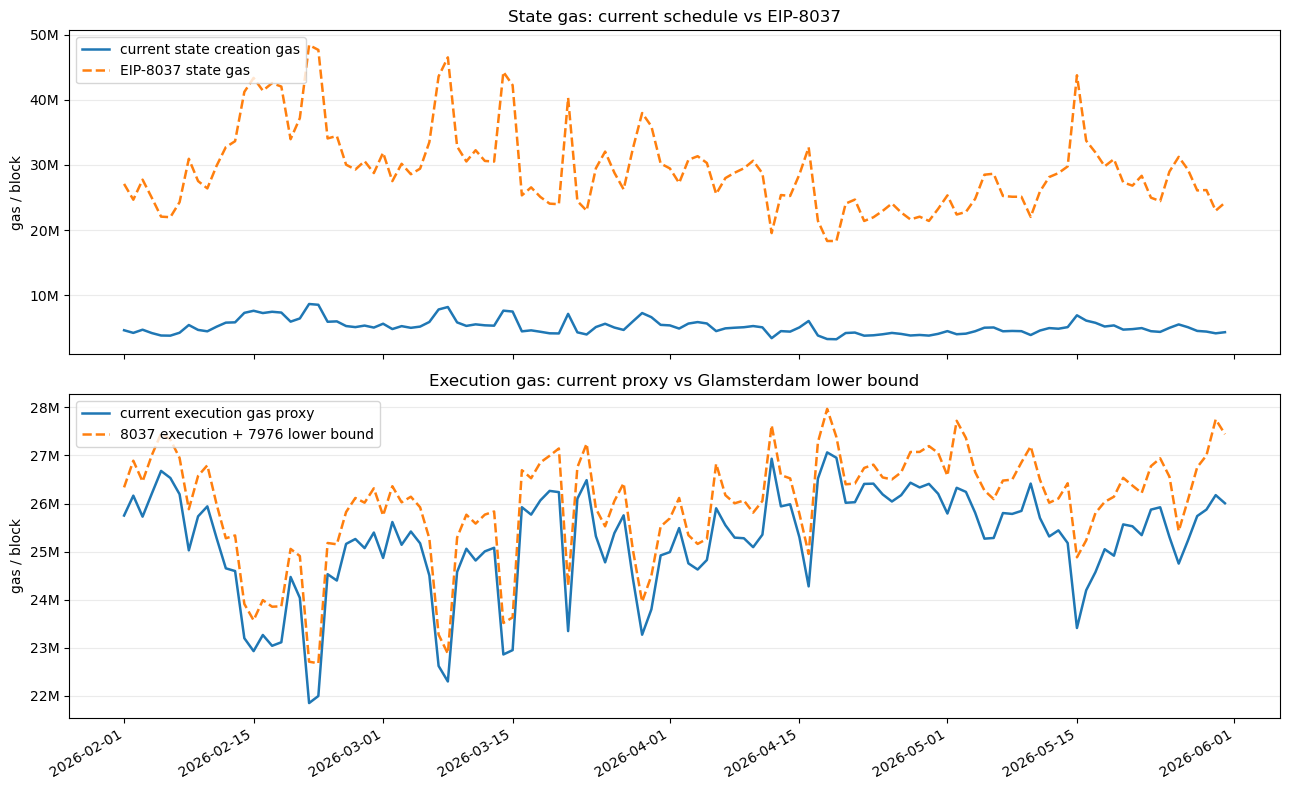

In [16]:
def gas_millions(x, pos):
    return f"{x / 1_000_000:.0f}M"

plot_df = panel.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(plot_df["date"], plot_df["current_state_creation_gas_per_block"], label="current state creation gas", linewidth=1.8)
axes[0].plot(plot_df["date"], plot_df["state_gas_8037_per_block"], label="EIP-8037 state gas", linewidth=1.8, linestyle="--")
axes[0].set_title("State gas: current schedule vs EIP-8037")
axes[0].set_ylabel("gas / block")
axes[0].yaxis.set_major_formatter(FuncFormatter(gas_millions))
axes[0].legend(loc="upper left")
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(plot_df["date"], plot_df["current_execution_gas_per_block"], label="current execution gas proxy", linewidth=1.8)
axes[1].plot(plot_df["date"], plot_df["execution_gas_8037_7976_lower_bound_per_block"], label="8037 execution + 7976 lower bound", linewidth=1.8, linestyle="--")
axes[1].set_title("Execution gas: current proxy vs Glamsterdam lower bound")
axes[1].set_ylabel("gas / block")
axes[1].yaxis.set_major_formatter(FuncFormatter(gas_millions))
axes[1].legend(loc="upper left")
axes[1].grid(axis="y", alpha=0.25)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(STATE_EXECUTION_PLOT, dpi=160)
STATE_EXECUTION_PLOT


PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/daily_accounting_bandwidth_bytes_2026-02-01_2026-06-01.png')

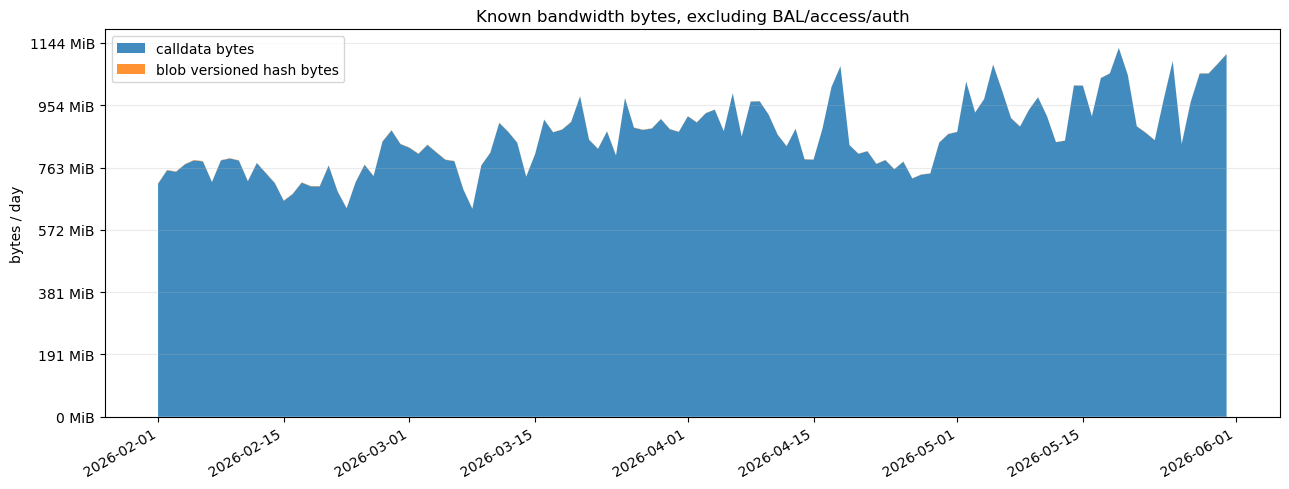

In [17]:
def bytes_mib(x, pos):
    return f"{x / 2**20:.0f} MiB"

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    plot_df["date"],
    plot_df["bandwidth_calldata_bytes"],
    plot_df["bandwidth_blob_hash_bytes"],
    labels=["calldata bytes", "blob versioned hash bytes"],
    alpha=0.85,
)
ax.set_title("Known bandwidth bytes, excluding BAL/access/auth")
ax.set_ylabel("bytes / day")
ax.yaxis.set_major_formatter(FuncFormatter(bytes_mib))
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(BANDWIDTH_BYTES_PLOT, dpi=160)
BANDWIDTH_BYTES_PLOT


## Calibration Gap

This notebook should be read as the large Xatu backbone, not the finished calibrated panel.

Next calibration items:

- **EIP-7981 access-list data gas:** requires RPC transaction access lists.
- **Authorization tuple bytes:** requires RPC raw transactions for EIP-7702 type-4 authorization lists.
- **Delegation indicators:** requires RPC authorization lists plus pre-state/account state.
- **BAL bytes:** requires trace-derived BAL construction or sampled imputation.
- **Exact transaction-level `8037_execution_gas`:** requires subtracting state-creation gas per transaction before applying the EIP-7976 floor. The current column is a lower bound using receipt body gas.
